In [ ]:
#!pip install kaggle

In [ ]:
# Set up Enviroment - libs, modules
import numpy as np
import os
import cv2
import itertools
import imutils
import shutil
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import zipfile
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16, preprocess_input
from keras import layers
from keras.models import Model, Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam, RMSprop
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import shutil

In [ ]:
# Following part I set up environment for download Kaggle dataset (brain tumor detection)
from google.colab import files
files.upload("kaggle.json")

Saving kaggle.json to kaggle.json/kaggle.json


{'kaggle.json/kaggle.json': b'{"username":"saidaalipanahova","key":"b46b10df65e2c0d86ffc2bf4e4e567e5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

kaggle.json  sample_data


In [ ]:
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
 79% 12.0M/15.1M [00:00<00:00, 21.2MB/s]
100% 15.1M/15.1M [00:00<00:00, 16.1MB/s]


In [ ]:
# Extract the contents of the brain MRI dataset ZIP file to a specified directory
zip_path = '/content/brain-mri-images-for-brain-tumor-detection.zip'
extract_path = '/content/brain_mri_dataset/'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)
os.listdir(extract_path)

['yes', 'no', 'brain_tumor_dataset']

In [ ]:
# Create the directory structure for training, testing, and validation datasets using the `mkdir` command
!mkdir -p /content/brain_tumor_dataset/TRAIN/YES /content/brain_tumor_dataset/TRAIN/NO
!mkdir -p /content/brain_tumor_dataset/TEST/YES /content/brain_tumor_dataset/TEST/NO
!mkdir -p /content/brain_tumor_dataset/VAL/YES /content/brain_tumor_dataset/VAL/NO

In [ ]:
# This function organizes and splits image data into training, validation, and test sets.
# It assumes a folder structure where each class is a subfolder containing images.
# The images are distributed into 'TRAIN', 'VAL', and 'TEST' folders according to the provided split ratios.
# The destination path should already contain the corresponding subdirectories (e.g., TRAIN/YES, TEST/NO, etc.).
# Each file is copied (not moved) from the source to its appropriate destination.
def split_and_copy(img_dir, dest_dir, split_ratios=(0.8, 0.15, 0.05)):
  for class_name in os.listdir(img_dir):
    if class_name.startswith('.'):
      continue

    full_class_path = os.path.join(img_dir, class_name)
    images = [f for f in os.listdir(full_class_path) if not f.startswith('.')]
    total = len(images)

    train_end = int(split_ratios[0] * total)
    val_end = train_end + int(split_ratios[1] * total)

    splits = {'TRAIN': images[:train_end], 'VAL': images[train_end:val_end],'TEST': images[val_end:] }

    for split, file_list in splits.items():
      for file in file_list:
        src = os.path.join(full_class_path, file)
        dst = os.path.join(dest_dir, split, class_name.upper(), file)
        shutil.copy(src, dst)
split_and_copy('brain_mri_dataset/brain_tumor_dataset/', 'brain_tumor_dataset/')


In [ ]:
# This function loads and preprocesses images from a given folder path.
# It assumes that each subfolder inside the main folder represents a different class label.
# For each image, it resizes to the specified size (default: 100x100), and assigns a numeric label.
# The function returns:
# - a NumPy array of processed images,
# - a NumPy array of corresponding numeric labels,
# - a dictionary mapping numeric labels to class names (e.g., {0: 'NO', 1: 'YES'}).
def load_images_from_folder(folder_path, img_size=(100, 100)):
  images = []
  labels = []
  label_dict = {}
  label_index = 0

  for class_folder in tqdm(sorted(os.listdir(folder_path))):
    if not class_folder.startswith('.'):
      label_dict[label_index] = class_folder
      class_path = os.path.join(folder_path, class_folder)
      for image_file in os.listdir(class_path):
        if not image_file.startswith('.'):
          image_path = os.path.join(class_path, image_file)
          image = cv2.imread(image_path)

          if image is None:
            continue
          image = cv2.resize(image, img_size)
          images.append(image)
          labels.append(label_index)
      label_index += 1
  images = np.array(images)
  labels = np.array(labels)

  print(f'{len(images)} images loaded from {folder_path}')
  return images, labels, label_dict

In [ ]:
# This function visualizes the confusion matrix using matplotlib.
# It's commonly used to evaluate classification models.
# Parameters:
# - conf_matrix: the confusion matrix (2D array)
# - class_names: a list of class labels (e.g., ['NO', 'YES'])
# - normalize: if True, normalizes the values to percentages
# - title: the title of the plot
# - colormap: defines the color style used in the heatmap
def display_confusion_matrix(conf_matrix, class_names, normalize=False, title='Confusion Matrix', colormap=plt.cm.Blues):
  plt.figure(figsize=(6, 6))
  plt.imshow(conf_matrix, interpolation='nearest', cmap=colormap)
  plt.title(title)
  plt.colorbar()

  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names, rotation=90)
  plt.yticks(tick_marks, class_names)

  if normalize:
    conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

  threshold = conf_matrix.max() / 2.
  conf_matrix = np.round(conf_matrix, 2)

  for i, j in itertools.product(range(conf_matrix.shape[0]), range(conf_matrix.shape[1])):
    plt.text(j, i, conf_matrix[i, j], horizontalalignment="center", color="white" if conf_matrix[i, j] > threshold else "black")

  plt.tight_layout()
  plt.ylabel('True Label')
  plt.xlabel('Predicted Label')
  plt.show()

In [ ]:
# This function loads image data from a directory using the previously defined function `load_images_from_folder`.
# It returns three items:
# - X: the list of images
# - y: the corresponding labels (integer encoding of classes)
# - labels: a dictionary of the class labels and their corresponding index
def load_data_from_directory(directory, img_size):
    X, y, labels = load_images_from_folder(directory, img_size)
    return X, y, labels
IMG_SIZE = (224, 224)
TRAIN_DIR = 'brain_tumor_dataset/TRAIN/'
TEST_DIR = 'brain_tumor_dataset/TEST/'
VAL_DIR = 'brain_tumor_dataset/VAL/'

X_train, y_train, labels_train = load_data_from_directory(TRAIN_DIR, IMG_SIZE)
X_test, y_test, labels_test = load_data_from_directory(TEST_DIR, IMG_SIZE)
X_val, y_val, labels_val = load_data_from_directory(VAL_DIR, IMG_SIZE)


100%|██████████| 2/2 [00:00<00:00,  4.25it/s]


203 images loaded from brain_tumor_dataset/TRAIN/


100%|██████████| 2/2 [00:00<00:00, 43.02it/s]


24 images loaded from brain_tumor_dataset/TEST/


100%|██████████| 2/2 [00:00<00:00, 15.49it/s]

51 images loaded from brain_tumor_dataset/VAL/


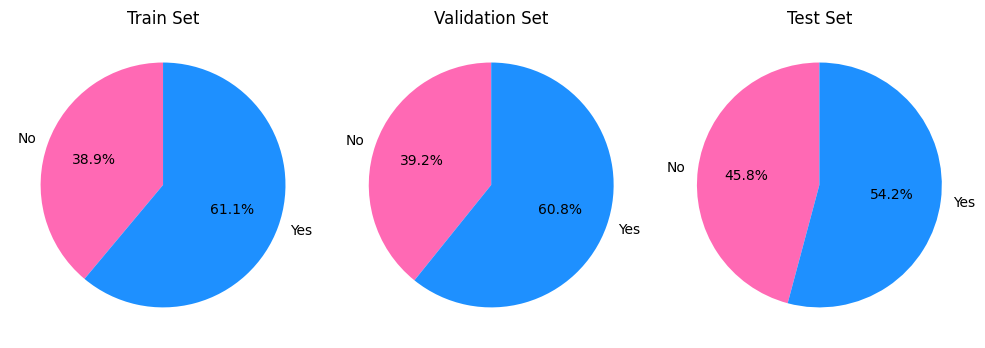

In [ ]:
# Count the number of images belonging to class '0' and class '1' in the training, validation, and test sets.
# '0' indicates the class label for 'No' (no tumor) and '1' indicates the class label for 'Yes' (tumor present).

counts_train = [np.sum(y_train == 0), np.sum(y_train == 1)]  # Count of 'No' and 'Yes' in the training set
counts_val = [np.sum(y_val == 0), np.sum(y_val == 1)]        # Count of 'No' and 'Yes' in the validation set
counts_test = [np.sum(y_test == 0), np.sum(y_test == 1)]      # Count of 'No' and 'Yes' in the test set

# Labels and corresponding colors for the pie chart segments
labels = ['No', 'Yes']  # 'No' means no tumor, 'Yes' means tumor present
colors = ['#FF69B4', '#1E90FF']  # Custom colors for the chart: pink for 'No' and blue for 'Yes'

# Create a figure with a size of 10x6 inches for the plots
plt.figure(figsize=(10, 6))

# Plot pie chart for the training set
plt.subplot(131)  # 1st subplot (1 row, 3 columns, 1st position)
plt.pie(counts_train, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Train Set')  # Title for the training set pie chart

# Plot pie chart for the validation set
plt.subplot(132)  # 2nd subplot (1 row, 3 columns, 2nd position)
plt.pie(counts_val, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Validation Set')  # Title for the validation set pie chart

# Plot pie chart for the test set
plt.subplot(133)  # 3rd subplot (1 row, 3 columns, 3rd position)
plt.pie(counts_test, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Test Set')  # Title for the test set pie chart

# Adjust layout to prevent overlapping subplots
plt.tight_layout()

# Display the pie charts
plt.show()


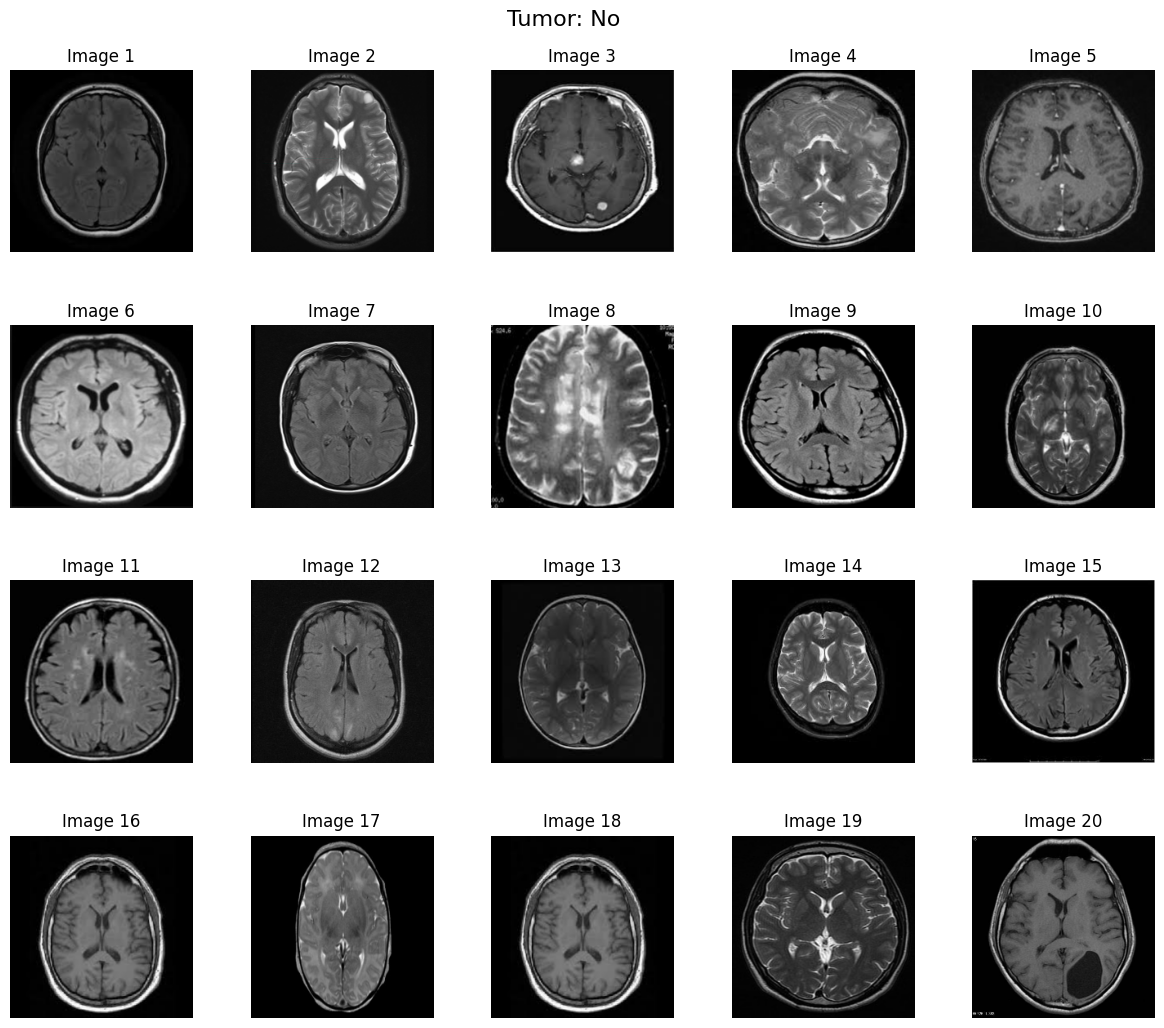

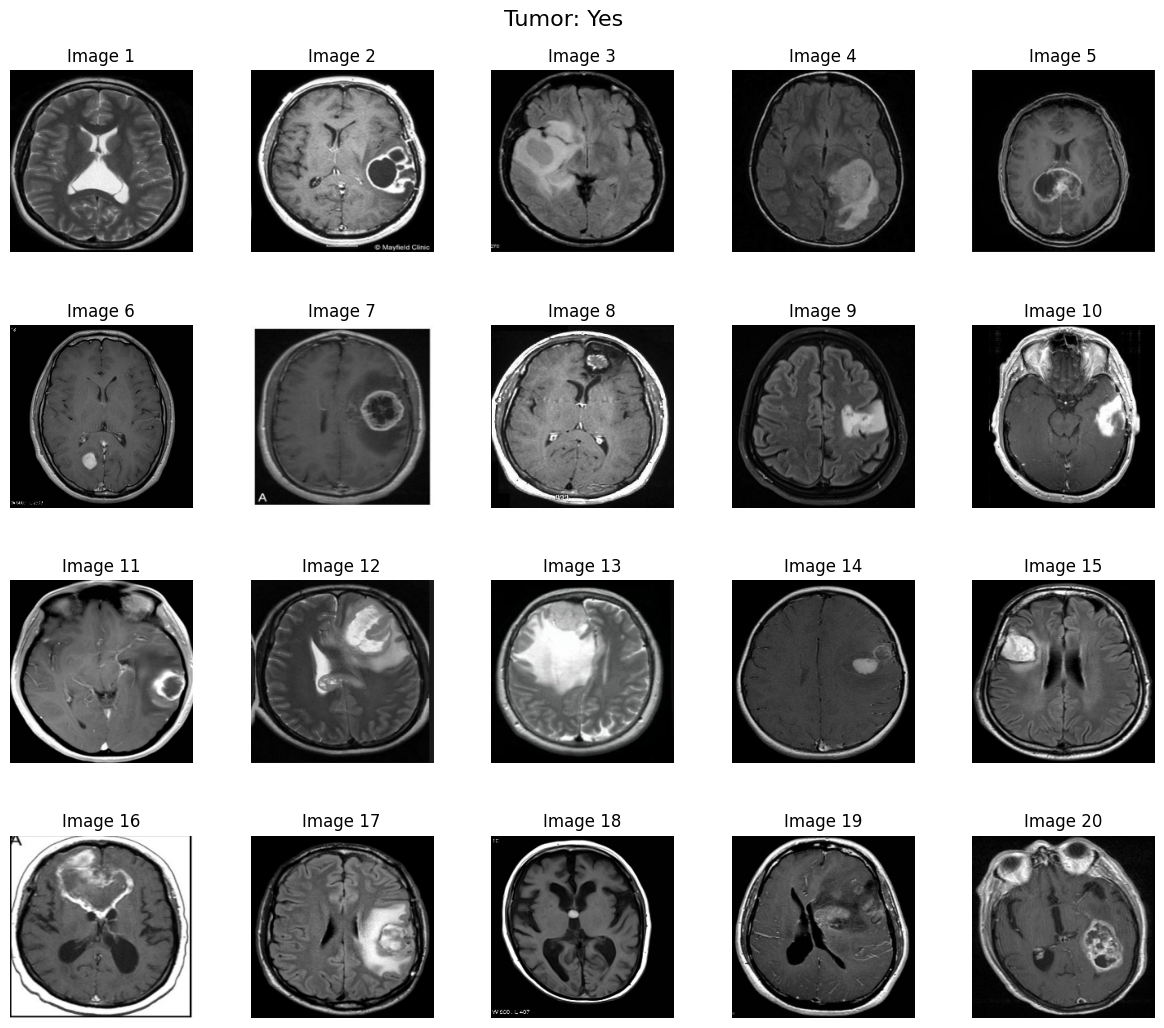

In [ ]:
# Displays a grid of sample images for each class in the dataset.
#
# Parameters:
# - X (array-like): A list or array containing image data.
# - y (array-like): Labels corresponding to the images in X.
# - labels_dict (dict): A dictionary mapping label indices to class names.
# - n (int): Number of images to show per class (default is 50).
# - columns (int): Number of columns in the grid (default is 5).
#
# The function loops over each class and displays up to 'n' images
# belonging to that class. Images are shown in a grid layout,
# with the class name as the title for each grid.
def plot_sample_version_1(X, y, labels_dict, n=50, columns=5):
  X = np.array(X)
  y = np.array(y)

  for index in range(len(labels_dict)):
    imgs_indices = np.where(y == index)[0][:n]
    imgs = X[imgs_indices]
    rows = int(np.ceil(n / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns*3, rows*3))
    axes = axes.flatten()
    for i, img in enumerate(imgs):
      ax = axes[i]
      ax.imshow(img)
      ax.axis('off')
      ax.set_title(f"Image {i+1}")
    for i in range(len(imgs), len(axes)):
      axes[i].axis('off')
    plt.subplots_adjust(hspace=0.4, top=0.9)
    fig.suptitle(f'Tumor: {labels_dict[index]}', fontsize=16, y=0.95)
    plt.show()

plot_sample_version_1(X_train, y_train, labels, 20)

In [ ]:
# This function detects and crops the tumor region from an MRI image by identifying the largest contour and applying a margin around it.
def crop_tumor(img, add_pixels=10):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  gray = cv2.GaussianBlur(gray, (5, 5), 0)
  thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
  thresh = cv2.erode(thresh, None, iterations=2)
  thresh = cv2.dilate(thresh, None, iterations=2)
# Contours
  cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cnts = imutils.grab_contours(cnts)

  if len(cnts) == 0:
    return img  # nothing found, return original
  c = max(cnts, key=cv2.contourArea)
# Extreme points
  extLeft = tuple(c[c[:, :, 0].argmin()][0])
  extRight = tuple(c[c[:, :, 0].argmax()][0])
  extTop = tuple(c[c[:, :, 1].argmin()][0])
  extBot = tuple(c[c[:, :, 1].argmax()][0])
# Apply margins and crop
  h, w = img.shape[:2]
  x1 = max(extLeft[0] - add_pixels, 0)
  x2 = min(extRight[0] + add_pixels, w)
  y1 = max(extTop[1] - add_pixels, 0)
  y2 = min(extBot[1] + add_pixels, h)

  cropped_img = img[y1:y2, x1:x2].copy()
  return cropped_img

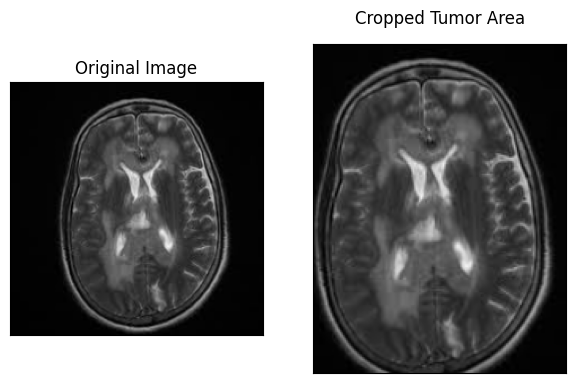

In [ ]:
# Sample visualization. We used picture which index =43 and this image has  more margines
img = X_train[43]
cropped = crop_tumor(img, add_pixels=10)
plt.figure(figsize=(15,6))
plt.subplot(141)
plt.imshow(img)
plt.xticks([]); plt.yticks([]); plt.title('Original Image')
plt.subplot(142)
plt.imshow(cropped)
plt.xticks([]); plt.yticks([]); plt.title('Cropped Tumor Area', pad=15)
plt.show()

In [ ]:
X_train_cropped = [cv2.resize(crop_tumor(img), (224, 224)) for img in X_train]
X_test_cropped = [cv2.resize(crop_tumor(img), (224, 224)) for img in X_test]
X_val_cropped = [cv2.resize(crop_tumor(img), (224, 224)) for img in X_val]


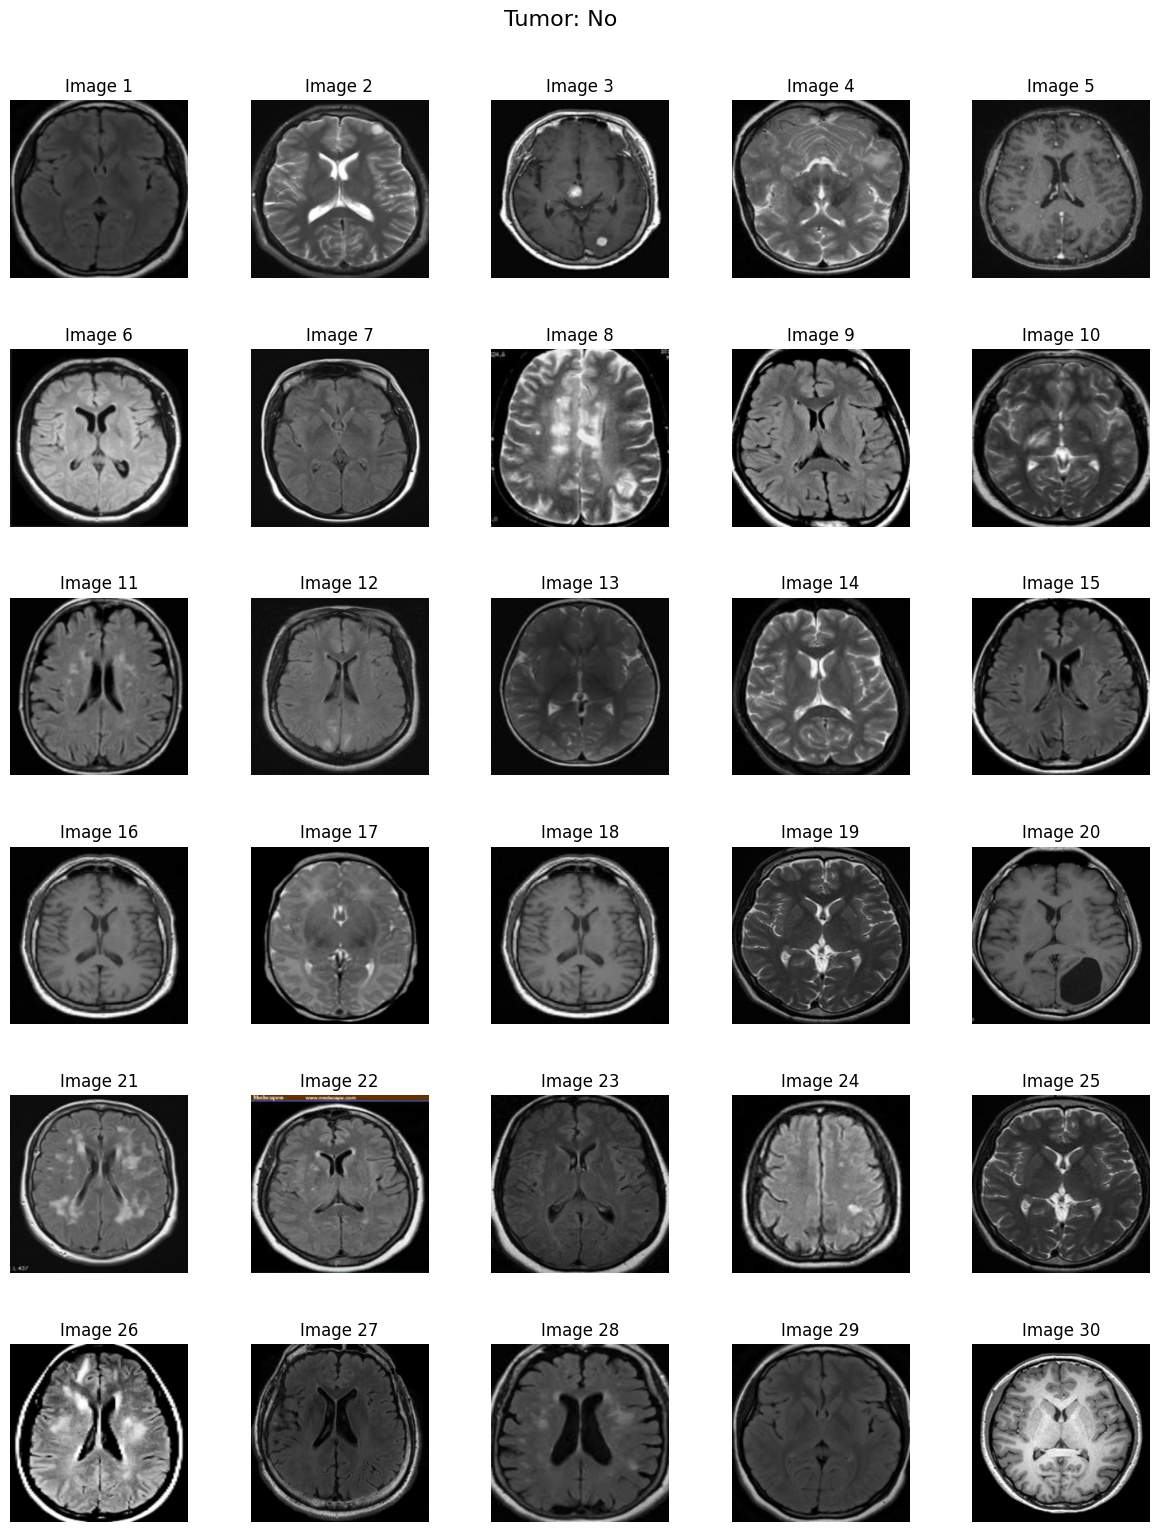

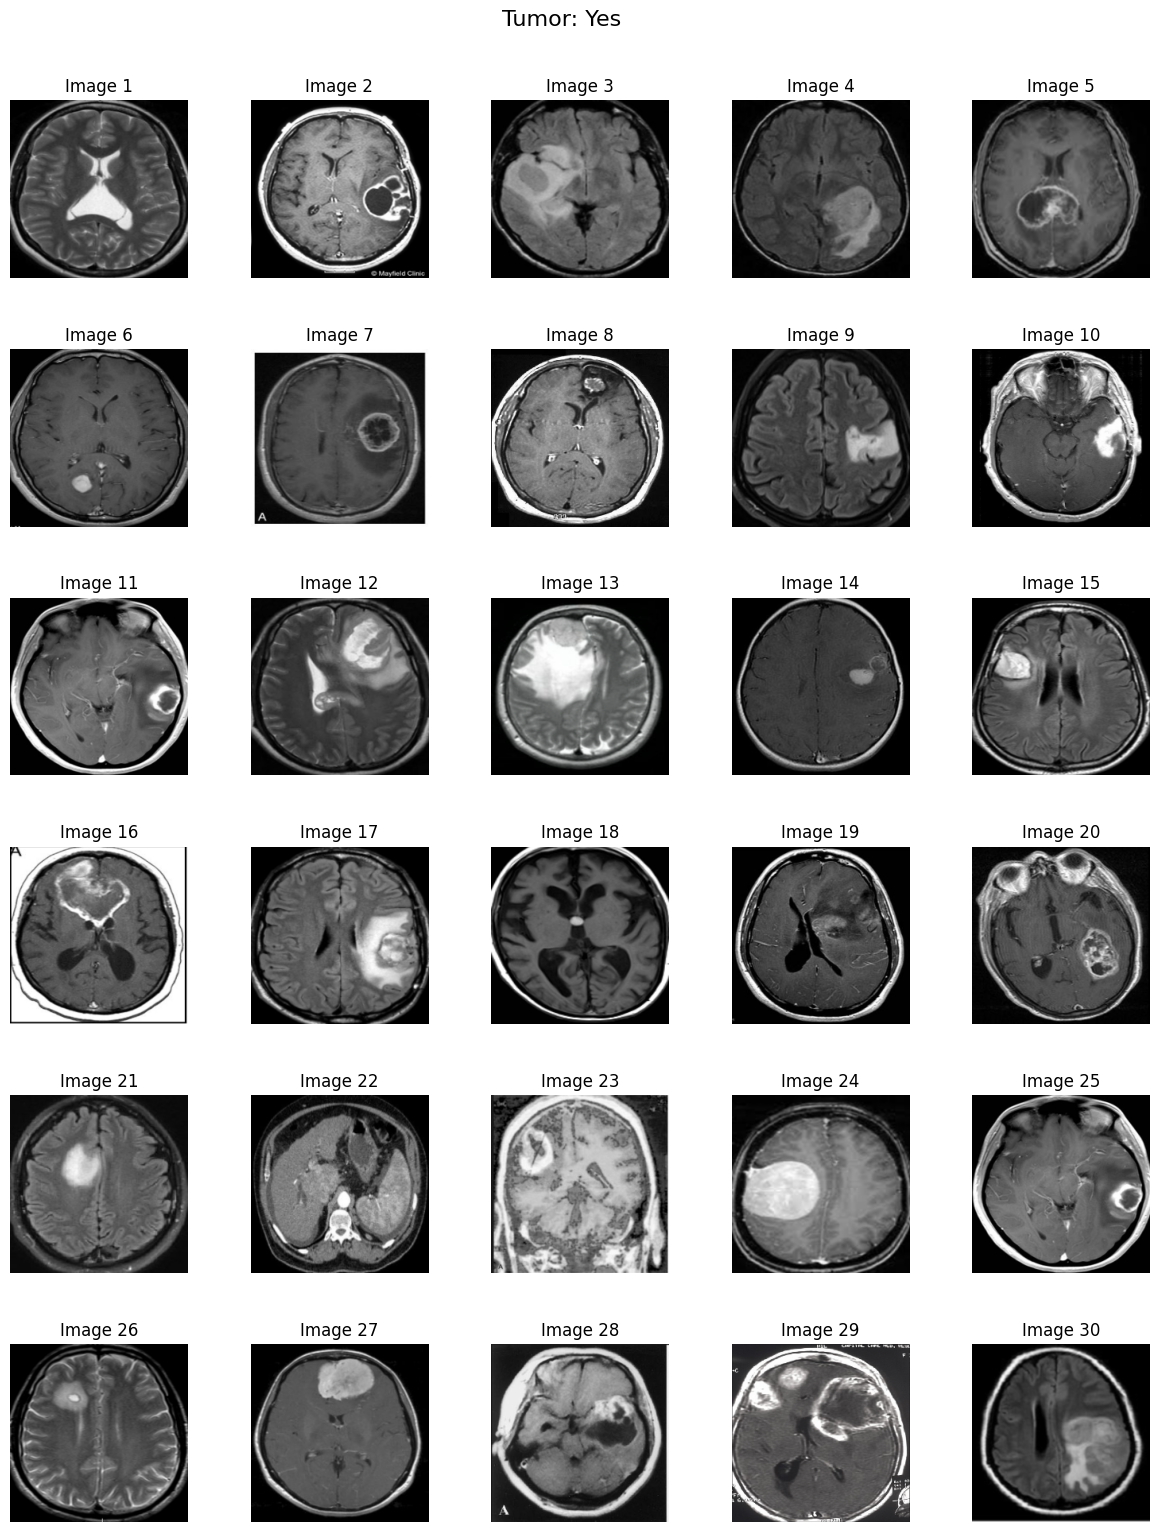

In [ ]:
plot_sample_version_1(X_train_cropped, y_train, labels, 30)

In [ ]:
!mkdir TRAIN_CROP TEST_CROP VAL_CROP TRAIN_CROP/YES TRAIN_CROP/NO TEST_CROP/YES TEST_CROP/NO VAL_CROP/YES VAL_CROP/NO

mkdir: cannot create directory ‘TRAIN_CROP’: File exists
mkdir: cannot create directory ‘TEST_CROP’: File exists
mkdir: cannot create directory ‘VAL_CROP’: File exists
mkdir: cannot create directory ‘TRAIN_CROP/YES’: File exists
mkdir: cannot create directory ‘TRAIN_CROP/NO’: File exists
mkdir: cannot create directory ‘TEST_CROP/YES’: File exists
mkdir: cannot create directory ‘TEST_CROP/NO’: File exists
mkdir: cannot create directory ‘VAL_CROP/YES’: File exists
mkdir: cannot create directory ‘VAL_CROP/NO’: File exists


In [ ]:
# This function saves images into 'NO' and 'YES' subfolders within a specified directory based on their class labels
def save_new_images(x_set, y_set, folder_name):
  no_folder = os.path.join(folder_name, 'NO')
  yes_folder = os.path.join(folder_name, 'YES')
  os.makedirs(no_folder, exist_ok=True)
  os.makedirs(yes_folder, exist_ok=True)
  i = 0
  for (img, imclass) in zip(x_set, y_set):
    if imclass == 0:
      cv2.imwrite(os.path.join(no_folder, f'{i}.jpg'), img)
    else:
      cv2.imwrite(os.path.join(yes_folder, f'{i}.jpg'), img)
    i += 1

In [ ]:
save_new_images(X_train_cropped, y_train, folder_name='TRAIN_CROP/')
save_new_images(X_val_cropped, y_val, folder_name='VAL_CROP/')
save_new_images(X_test_cropped, y_test, folder_name='TEST_CROP/')

In [ ]:
#Delete this part
def image_preprocesing(set_name, img_size):
  set_new = []
  for img in set_name:
    img = cv2.resize(img, dsize=img_size, interpolation=cv2.INTER_CUBIC)
    set_new.append(preprocess_input(img))
  return np.array(set_new)

In [ ]:
def image_preprocessing(set_name, img_size):
  return np.array([preprocess_input(cv2.resize(img, dsize=img_size, interpolation=cv2.INTER_CUBIC))for img in set_name])

In [ ]:
X_train_prep = image_preprocessing(set_name=X_train_cropped, img_size=IMG_SIZE)
X_test_prep = image_preprocessing(set_name=X_test_cropped, img_size=IMG_SIZE)
X_val_prep = image_preprocessing(set_name=X_val_cropped, img_size=IMG_SIZE)

In [ ]:
# Delete this
demo_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    rescale=1./255,
    shear_range=0.05,
    brightness_range=[0.1, 1.5],
    horizontal_flip=True,
    vertical_flip=True
)

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.3, 1.2],
    rotation_range=20,
    shear_range=10,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

In [ ]:
if not os.path.exists('preview'):
    os.mkdir('preview')
x = X_train_cropped[0]
x = x.reshape((1,) + x.shape)
i = 0
for batch in datagen.flow(x, batch_size=1, save_to_dir='preview', save_prefix='aug_img', save_format='jpg'):
    i += 1
    if i > 20:
        break

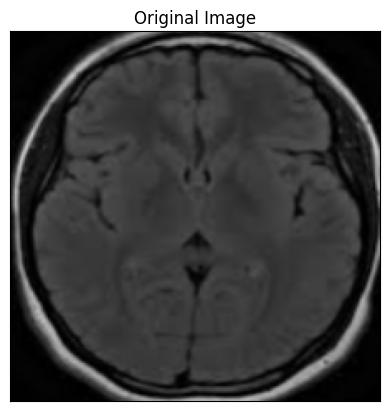

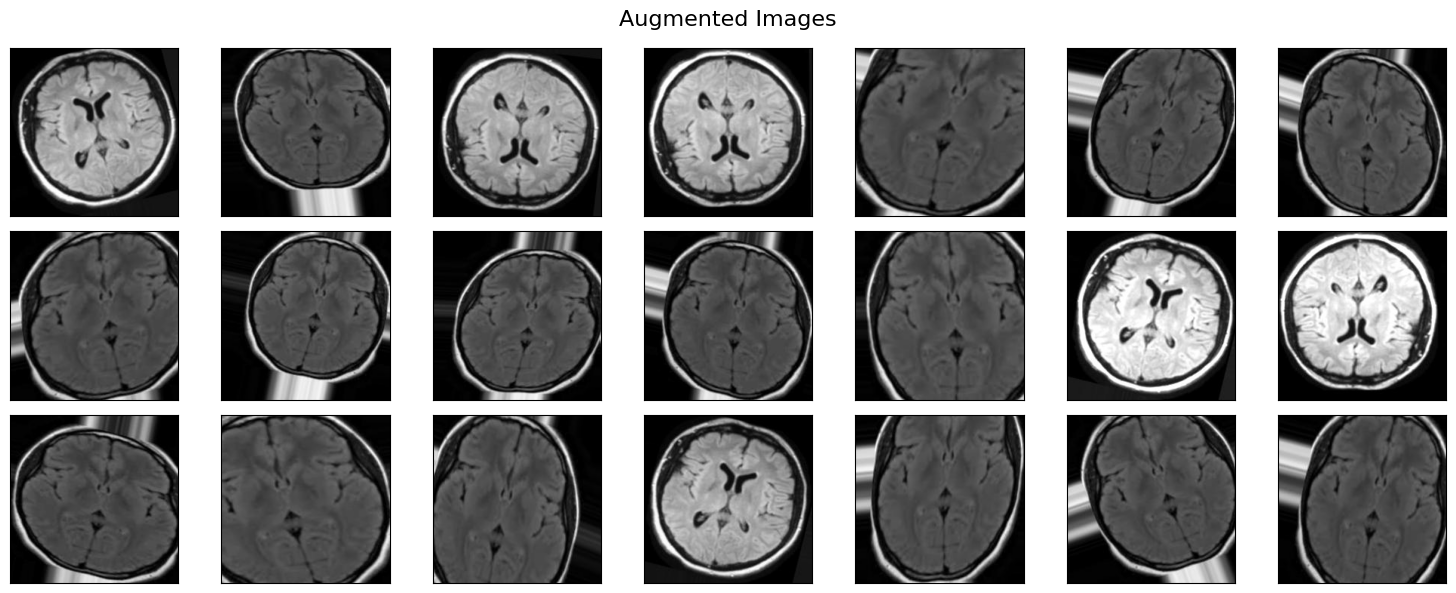

In [ ]:
plt.imshow(X_train_cropped[0])
plt.xticks([])
plt.yticks([])
plt.title('Original Image')
plt.show()
plt.figure(figsize=(15, 6))
i = 1
for img_name in os.listdir('preview/'):
    img_path = os.path.join('preview', img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 7, i)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    i += 1
    if i > 3 * 7:
        break
plt.suptitle("Augmented Images", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
#delete this

TRAIN_DIR = 'TRAIN_CROP/'
VAL_DIR = 'VAL_CROP/'
RANDOM_SEED = 123
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    seed=RANDOM_SEED
)

validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    seed=RANDOM_SEED
)

Found 208 images belonging to 2 classes.
Found 52 images belonging to 2 classes.


In [ ]:
RANDOM_SEED = 123
TRAIN_DIR = 'TRAIN_CROP/'
VAL_DIR = 'VAL_CROP/'
IMG_SIZE = (224, 224)  # For example, a size for the images, modify according to your needs

# ImageDataGenerator for test data
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ImageDataGenerator for training data with data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    seed=RANDOM_SEED
)

# Validation data generator
validation_generator = test_datagen.flow_from_directory(
    directory=VAL_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    seed=RANDOM_SEED
)


Found 208 images belonging to 2 classes.
Found 52 images belonging to 2 classes.


In [ ]:
#Delete this
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

IMG_SIZE = (128, 128)  # örnek
input_shape = IMG_SIZE + (3,)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification için
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
IMG_SIZE = (128, 128)  # example image size, modify as needed
input_shape = IMG_SIZE + (3,)

model = Sequential([
    # First convolutional block
    Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Second convolutional block with 128 filters
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Third convolutional block with 32 filters
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    # Flatten layer
    Flatten(),

    # Fully connected layers
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # for binary classification
])


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
IMG_SIZE = (224, 224)
input_shape = IMG_SIZE + (3,)
base_model = VGG16(weights='imagenet', include_top=False,input_shape=input_shape)

In [ ]:
# Define the number of output classes (binary classification)
# Load the VGG16 base model without the top layers
# Freeze the layers of the base model to prevent training on them
# Build the model with a GlobalAveragePooling2D layer and a dropout layer
# Compile the model with a smaller learning rate for RMSprop optimizer
# Display the architecture of the model
NUM_CLASSES = 1
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dropout(0.4),  # Adjusted dropout rate to 0.4
    layers.Dense(NUM_CLASSES, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=5e-5),  # Reduced learning rate
    metrics=['accuracy']
)
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │          25,089 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
EPOCHS = 30
# Define EarlyStopping callback
es = EarlyStopping(
    monitor='val_accuracy',  # Updated to match the correct metric name
    mode='max',
    patience=6,
    restore_best_weights=True  # Optional: restores model weights from the epoch with the best value of the monitored quantity
)
# Calculate steps_per_epoch for train generator
num_train_samples = train_generator.samples  # Total number of training samples
batch_size = train_generator.batch_size  # Batch size
steps_per_epoch = num_train_samples // batch_size  # Calculate steps per epoch
# If the number of samples is not divisible by the batch size, add an extra step
if num_train_samples % batch_size != 0:
    steps_per_epoch += 1
# Calculate validation_steps for validation generator
num_val_samples = validation_generator.samples  # Total number of validation samples
validation_steps = num_val_samples // batch_size  # Calculate validation steps
# If the number of validation samples is not divisible by the batch size, add an extra step
if num_val_samples % batch_size != 0:
    validation_steps += 1
# Train the model using the fit() method
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,  # Dynamically calculated steps_per_epoch
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,  # Dynamically calculated validation_steps
    callbacks=[es]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 150s 21s/step - accuracy: 0.4667 - loss: 4.6106 - val_accuracy: 0.5625 - val_loss: 2.6983
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 200s 30s/step - accuracy: 0.5811 - loss: 3.4727 - val_accuracy: 0.5938 - val_loss: 2.2472
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 146s 21s/step - accuracy: 0.6493 - loss: 3.0259 - val_accuracy: 0.4375 - val_loss: 2.2128
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 260s 31s/step - accuracy: 0.6234 - loss: 3.5010 - val_accuracy: 0.6562 - val_loss: 1.6422
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 203s 21s/step - accuracy: 0.6151 - loss: 3.1126 - val_accuracy: 0.6875 - val_loss: 1.3321
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 201s 32s/step - accuracy: 0.6788 - loss: 2.7886 - val_accuracy: 0.6875 - val_loss: 1.9923
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 201s 30s/step - accuracy: 0.6929 - loss: 2.6341 - val_accuracy: 0.6875 - val_loss: 1.5727
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 146s 21s/step - accuracy: 0.6393 - loss: 2.7231 - val_accuracy: 0.6250 - val_loss:

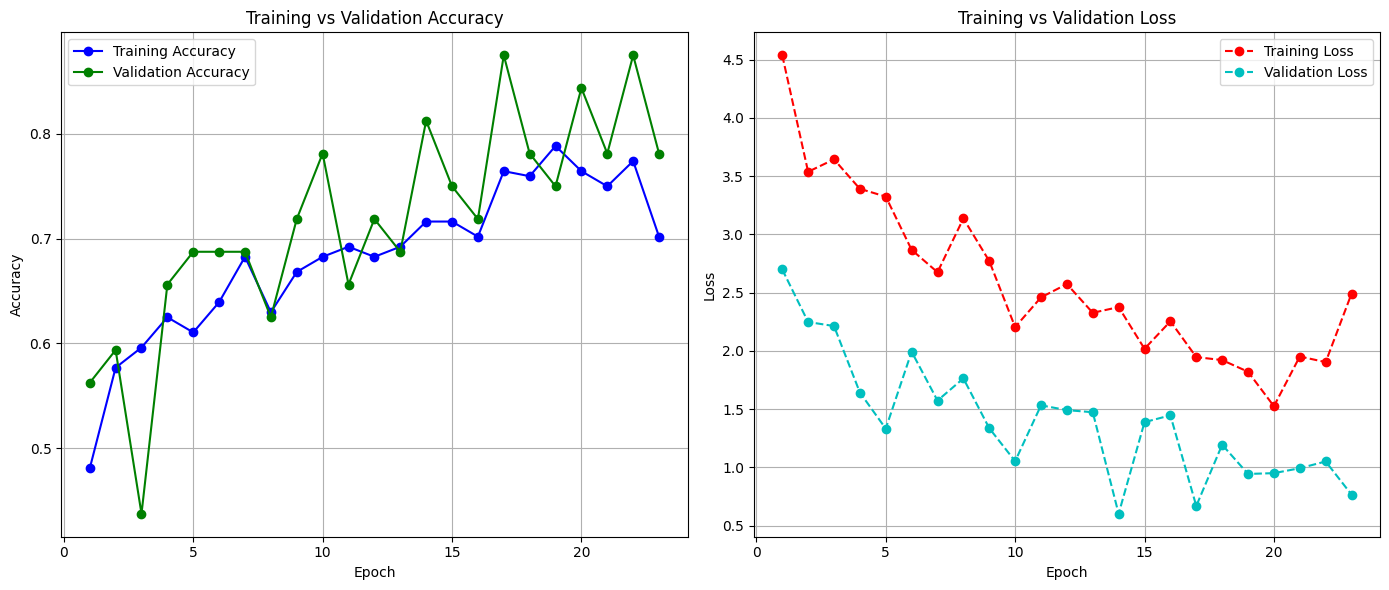

In [ ]:
# Visualize training and validation accuracy & loss over epochs

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'ro--', label='Training Loss')
plt.plot(epochs, val_loss, 'co--', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 15s/step
Validation Accuracy = 0.76


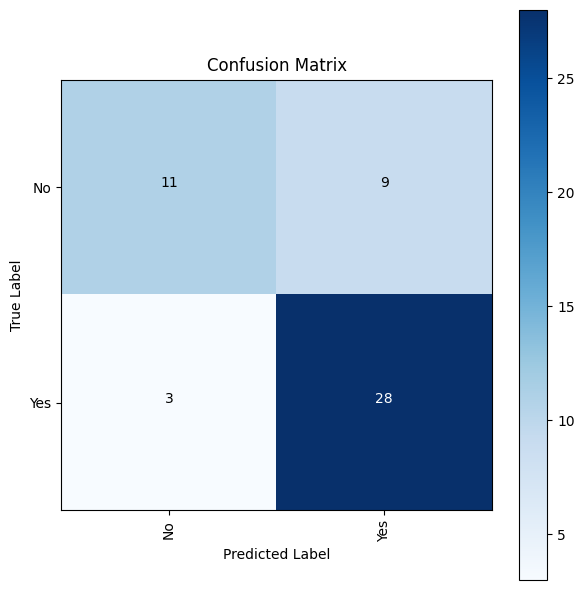

In [ ]:
# Prediction thresholds
y_pred_probs = model.predict(X_val_prep)
predictions = [int(prob[0] > 0.5) for prob in y_pred_probs]

# Compute accuracy correctly
accuracy = accuracy_score(y_val, predictions)
print('Validation Accuracy = %.2f' % accuracy)

# Confusion matrix
conf_matrix = confusion_matrix(y_val, predictions)
class_names = labels
cm_plot = display_confusion_matrix(conf_matrix, class_names=class_names, normalize=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
Test Accuracy = 0.71


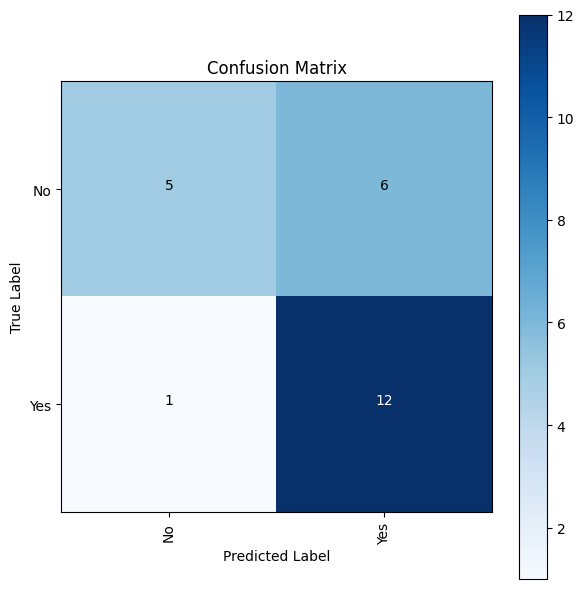

In [ ]:
# validate on test set
y_preds_test = model.predict(X_test_prep)
y_preds_test = [1 if x > 0.5 else 0 for x in y_preds_test]

test_accuracy = accuracy_score(y_test, y_preds_test)
print('Test Accuracy = %.2f' % test_accuracy)

class_names = labels
conf_matrix = confusion_matrix(y_test, y_preds_test)
cm_display = display_confusion_matrix(conf_matrix, class_names=class_names, normalize=False)
